# A dependency network in *Alice’s Adventures in Wonderland*
**Author: Akhmed Dugrichilov**  
Assignment 1 for Linguistic Data: Quantitative Analysis and Visualisation


## 1. Text
I use Lewis Carroll’s complete English novel *Alice’s Adventures in Wonderland* (1865), Project Gutenberg ebook 11.

## 2. Lemmatization
I parse the original word forms with spaCy’s `en_core_web_sm` model and then replace node labels with lower-case lemmas. Parsing an already lemmatized string would remove grammatical information and could change the dependency analysis. Lemmatization and parsing are therefore performed together on the original text.

Paragraphs are processed separately to keep memory use small; wrapped lines inside paragraphs become spaces. Every non-space token, including punctuation, is retained in the token table and lemmatized output.

In [ ]:
%pip install -r requirements.txt

In [15]:
from pathlib import Path
from collections import Counter
import csv, json, re, math
import spacy
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display, Image

In [16]:
BASE = Path.cwd()
assert (BASE / 'data/alice_original.txt').exists(), 'Open the notebook from its submission folder.'
OUT = BASE / 'outputs'
OUT.mkdir(exist_ok=True)
TARGET = 'queen'
print('spaCy:', spacy.__version__, '| NetworkX:', nx.__version__)

spaCy: 3.8.16 | NetworkX: 3.7


In [17]:
def save_csv(name, rows, fields):
    with (OUT / name).open('w', encoding='utf-8', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fields)
        writer.writeheader()
        writer.writerows(rows)

In [18]:
raw = (BASE / 'data/alice_original.txt').read_text(encoding='utf-8-sig')
body = raw.split('*** START OF THE PROJECT GUTENBERG EBOOK', 1)[1].split('***', 1)[1]
body = body.split('*** END OF THE PROJECT GUTENBERG EBOOK', 1)[0]
body = body[body.index('CHAPTER I.\n'):]
chapter_pattern = r'(?m)^CHAPTER [IVXLCDM]+\.\n[^\n]+\n'
assert len(re.findall(chapter_pattern, body)) == 12
body = re.sub(chapter_pattern, '', body)
body = re.sub(r'\[Illustration[^\]]*\]', '', body)
body = body.replace("_", "")
paragraphs = [re.sub(r'\s+', ' ', s).strip() for s in re.split(r'\n\s*\n', body) if s.strip()]
(BASE / 'data/alice_clean.txt').write_text('\n\n'.join(paragraphs), encoding='utf-8')
nlp = spacy.load('en_core_web_sm', disable=['ner'])
docs = list(nlp.pipe(paragraphs, batch_size=32))
token_rows, sentences, lemma_lines = [], {}, []
offset = 0
for paragraph_id, doc in enumerate(docs, 1):
    for sentence_id, sent in enumerate(doc.sents, 1):
        sid = f'{paragraph_id}:{sentence_id}'
        sentences[sid] = sent.text
        lemma_lines.append(' '.join(t.lemma_.lower() for t in sent if not t.is_space))
        for t in sent:
            if not t.is_space:
                token_rows.append(dict(token_id=offset+t.i, paragraph_id=paragraph_id,
                    sentence_id=sid, text=t.text, lemma=t.lemma_.lower(), pos=t.pos_,
                    dependency=t.dep_, head_id=offset+t.head.i, head_lemma=t.head.lemma_.lower()))
    offset += len(doc)
save_csv('tokens.csv', token_rows, list(token_rows[0]))
(OUT / 'lemmatized_novel.txt').write_text('\n'.join(lemma_lines), encoding='utf-8')
freq = Counter(t['lemma'] for t in token_rows if t['pos'] not in {'PUNCT', 'SPACE', 'SYM'})
print('Chapters: 12 | Paragraphs:', len(docs), '| Sentences:', len(sentences))
print('Non-space tokens:', len(token_rows), '| Word-like tokens:', sum(freq.values()))
print('Target frequency:', freq[TARGET])
print('Most frequent nouns/proper nouns:', Counter(t['lemma'] for t in token_rows if t['pos'] in {'NOUN','PROPN'}).most_common(20))


Chapters: 12 | Paragraphs: 799 | Sentences: 1521
Non-space tokens: 34533 | Word-like tokens: 27216
Target frequency: 74
Most frequent nouns/proper nouns: [('alice', 395), ('thing', 80), ('time', 77), ('queen', 74), ('king', 64), ('head', 60), ('turtle', 60), ('way', 57), ('hatter', 57), ('mock', 55), ('gryphon', 55), ('cat', 50), ('voice', 50), ('rabbit', 49), ('mouse', 47), ('duchess', 42), ('tone', 42), ('dormouse', 40), ('eye', 35), ('march', 34)]


## 3. Direct and secondary dependencies
For every occurrence of `queen`, I extract all children and, separately, every child of each child, using the original token-level parse. Punctuation and function words are included because the task requests all children; whitespace tokens are excluded.

The occurrence table records token IDs, relations, sentence IDs, and complete sentences, so every edge can be checked. Depth 1 is queen → child; depth 2 is child → grandchild. An edge weight counts token-level dependency instances.


In [19]:
occurrences = []
sentence_lookup = {r["token_id"]: r["sentence_id"] for r in token_rows}
offset = 0
target_count = 0
for doc in docs:
    for target in doc:
        if target.lemma_.lower() != TARGET:
            continue
        target_count += 1
        for child in target.children:
            if child.is_space:
                continue
            for depth, head, dependent in [(1, target, child)] + [(2, child, gc) for gc in child.children if not gc.is_space]:
                occurrences.append(dict(target_id=offset+target.i, sentence_id=sentence_lookup[offset+target.i], depth=depth,
                    head_id=offset+head.i, head_lemma=head.lemma_.lower(),
                    dependent_id=offset+dependent.i, dependent_lemma=dependent.lemma_.lower(),
                    relation=dependent.dep_, sentence=target.sent.text))
    offset += len(doc)
assert target_count == freq[TARGET]
save_csv('dependency_occurrences.csv', occurrences, list(occurrences[0]))
print('Target occurrences:', target_count)
print('Dependency instances by depth:', dict(Counter(r['depth'] for r in occurrences)))
print('Direct dependent lemmas:', Counter(r['dependent_lemma'] for r in occurrences if r['depth']==1).most_common())
print('Secondary dependent lemmas:', Counter(r['dependent_lemma'] for r in occurrences if r['depth']==2).most_common())

Target occurrences: 74
Dependency instances by depth: {1: 97, 2: 24}
Direct dependent lemmas: [('the', 71), (',', 6), ('’s', 6), ('of', 3), ('"', 2), ('!', 1), ('child', 1), ('examine', 1), ('pass', 1), ('talk', 1), ('and', 1), ('alice', 1), ('read', 1), ('furiously', 1)]
Secondary dependent lemmas: [('who', 4), ('be', 4), ('hearts', 3), ('at', 2), ('the', 1), ('royal', 1), (',', 1), ('and', 1), ('everybody', 1), ('have', 1), ('meanwhile', 1), ('rose', 1), ('all', 1), ('once', 1), ('list', 1)]


In [20]:
preview = pd.DataFrame(occurrences)[[
    "depth",
    "head_lemma",
    "dependent_lemma",
    "relation",
    "sentence"
]].head(10)

preview.columns = [
    "Depth",
    "Head",
    "Dependent",
    "Dependency relation",
    "Sentence"
]

display(
    preview.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "left",
        "white-space": "normal",
        "padding": "8px"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "left"),
                ("background-color", "#eaf0f6"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even)",
            "props": [("background-color", "#f5f5f5")]
        }
    ])
    .set_caption("First 10 extracted dependency instances")
)

Depth,Head,Dependent,Dependency relation,Sentence
1,queen,the,det,An invitation from the Queen to play croquet.”
1,queen,the,det,"The Frog-Footman repeated, in the same solemn tone, only changing the order of the words a little, “From the Queen."
1,queen,the,det,"“I must go and get ready to play croquet with the Queen,” and she hurried out of the room."
1,queen,the,det,“Do you play croquet with the Queen to-day?”
1,queen,the,det,"“We quarrelled last March—just before he went mad, you know—” (pointing with his tea spoon at the March Hare,) “—it was at the great concert given by the Queen of Hearts, and I had to sing"
1,queen,of,prep,"“We quarrelled last March—just before he went mad, you know—” (pointing with his tea spoon at the March Hare,) “—it was at the great concert given by the Queen of Hearts, and I had to sing"
2,of,hearts,pobj,"“We quarrelled last March—just before he went mad, you know—” (pointing with his tea spoon at the March Hare,) “—it was at the great concert given by the Queen of Hearts, and I had to sing"
1,queen,the,det,"“Well, I’d hardly finished the first verse,” said the Hatter, “when the Queen jumped up and bawled out, ‘He’s murdering the time!"
1,queen,the,det,“I heard the Queen say only yesterday you deserved to be beheaded!”
1,queen,the,det,"Two began in a low voice, “Why the fact is, you see, Miss, this here ought to have been a red rose-tree, and we put a white one in by mistake; and if the Queen was to find it out, we should all have our heads cut off, you know."


## 4. Graph construction
I use a **directed, weighted, layered graph**. Arrows run from head to dependent. A node is a `(depth, lemma)` pair: the same lemma at two depths has two nodes. This preserves the requested centre–children–grandchildren layout and avoids conflating different syntactic roles. Repeated instances within a layer are merged. Secondary nodes may have several parents; the drawing then represents an aggregate network, not a single dependency tree.

Node colours distinguish dependency depth: orange marks the target,
blue marks direct dependents, and green marks secondary dependents.
This makes the two levels easy to distinguish.

Node area is calculated as `180 + 95 × sqrt(count)`. For the target,
count is its frequency in the novel; for other nodes, it is the number
of extracted dependent instances. Square-root scaling keeps frequent
items visible without making rare items too small.

Edge width is calculated as `0.6 + log2(1 + weight)`, where weight
counts dependency instances. Logarithmic scaling makes frequency
differences visible without allowing the most frequent edge to
dominate the drawing. Edge labels show exact counts.

A directed graph preserves the head-to-dependent relationship.
Positions place the target at the centre, direct dependents on the
inner circle, and secondary dependents on the outer circle.

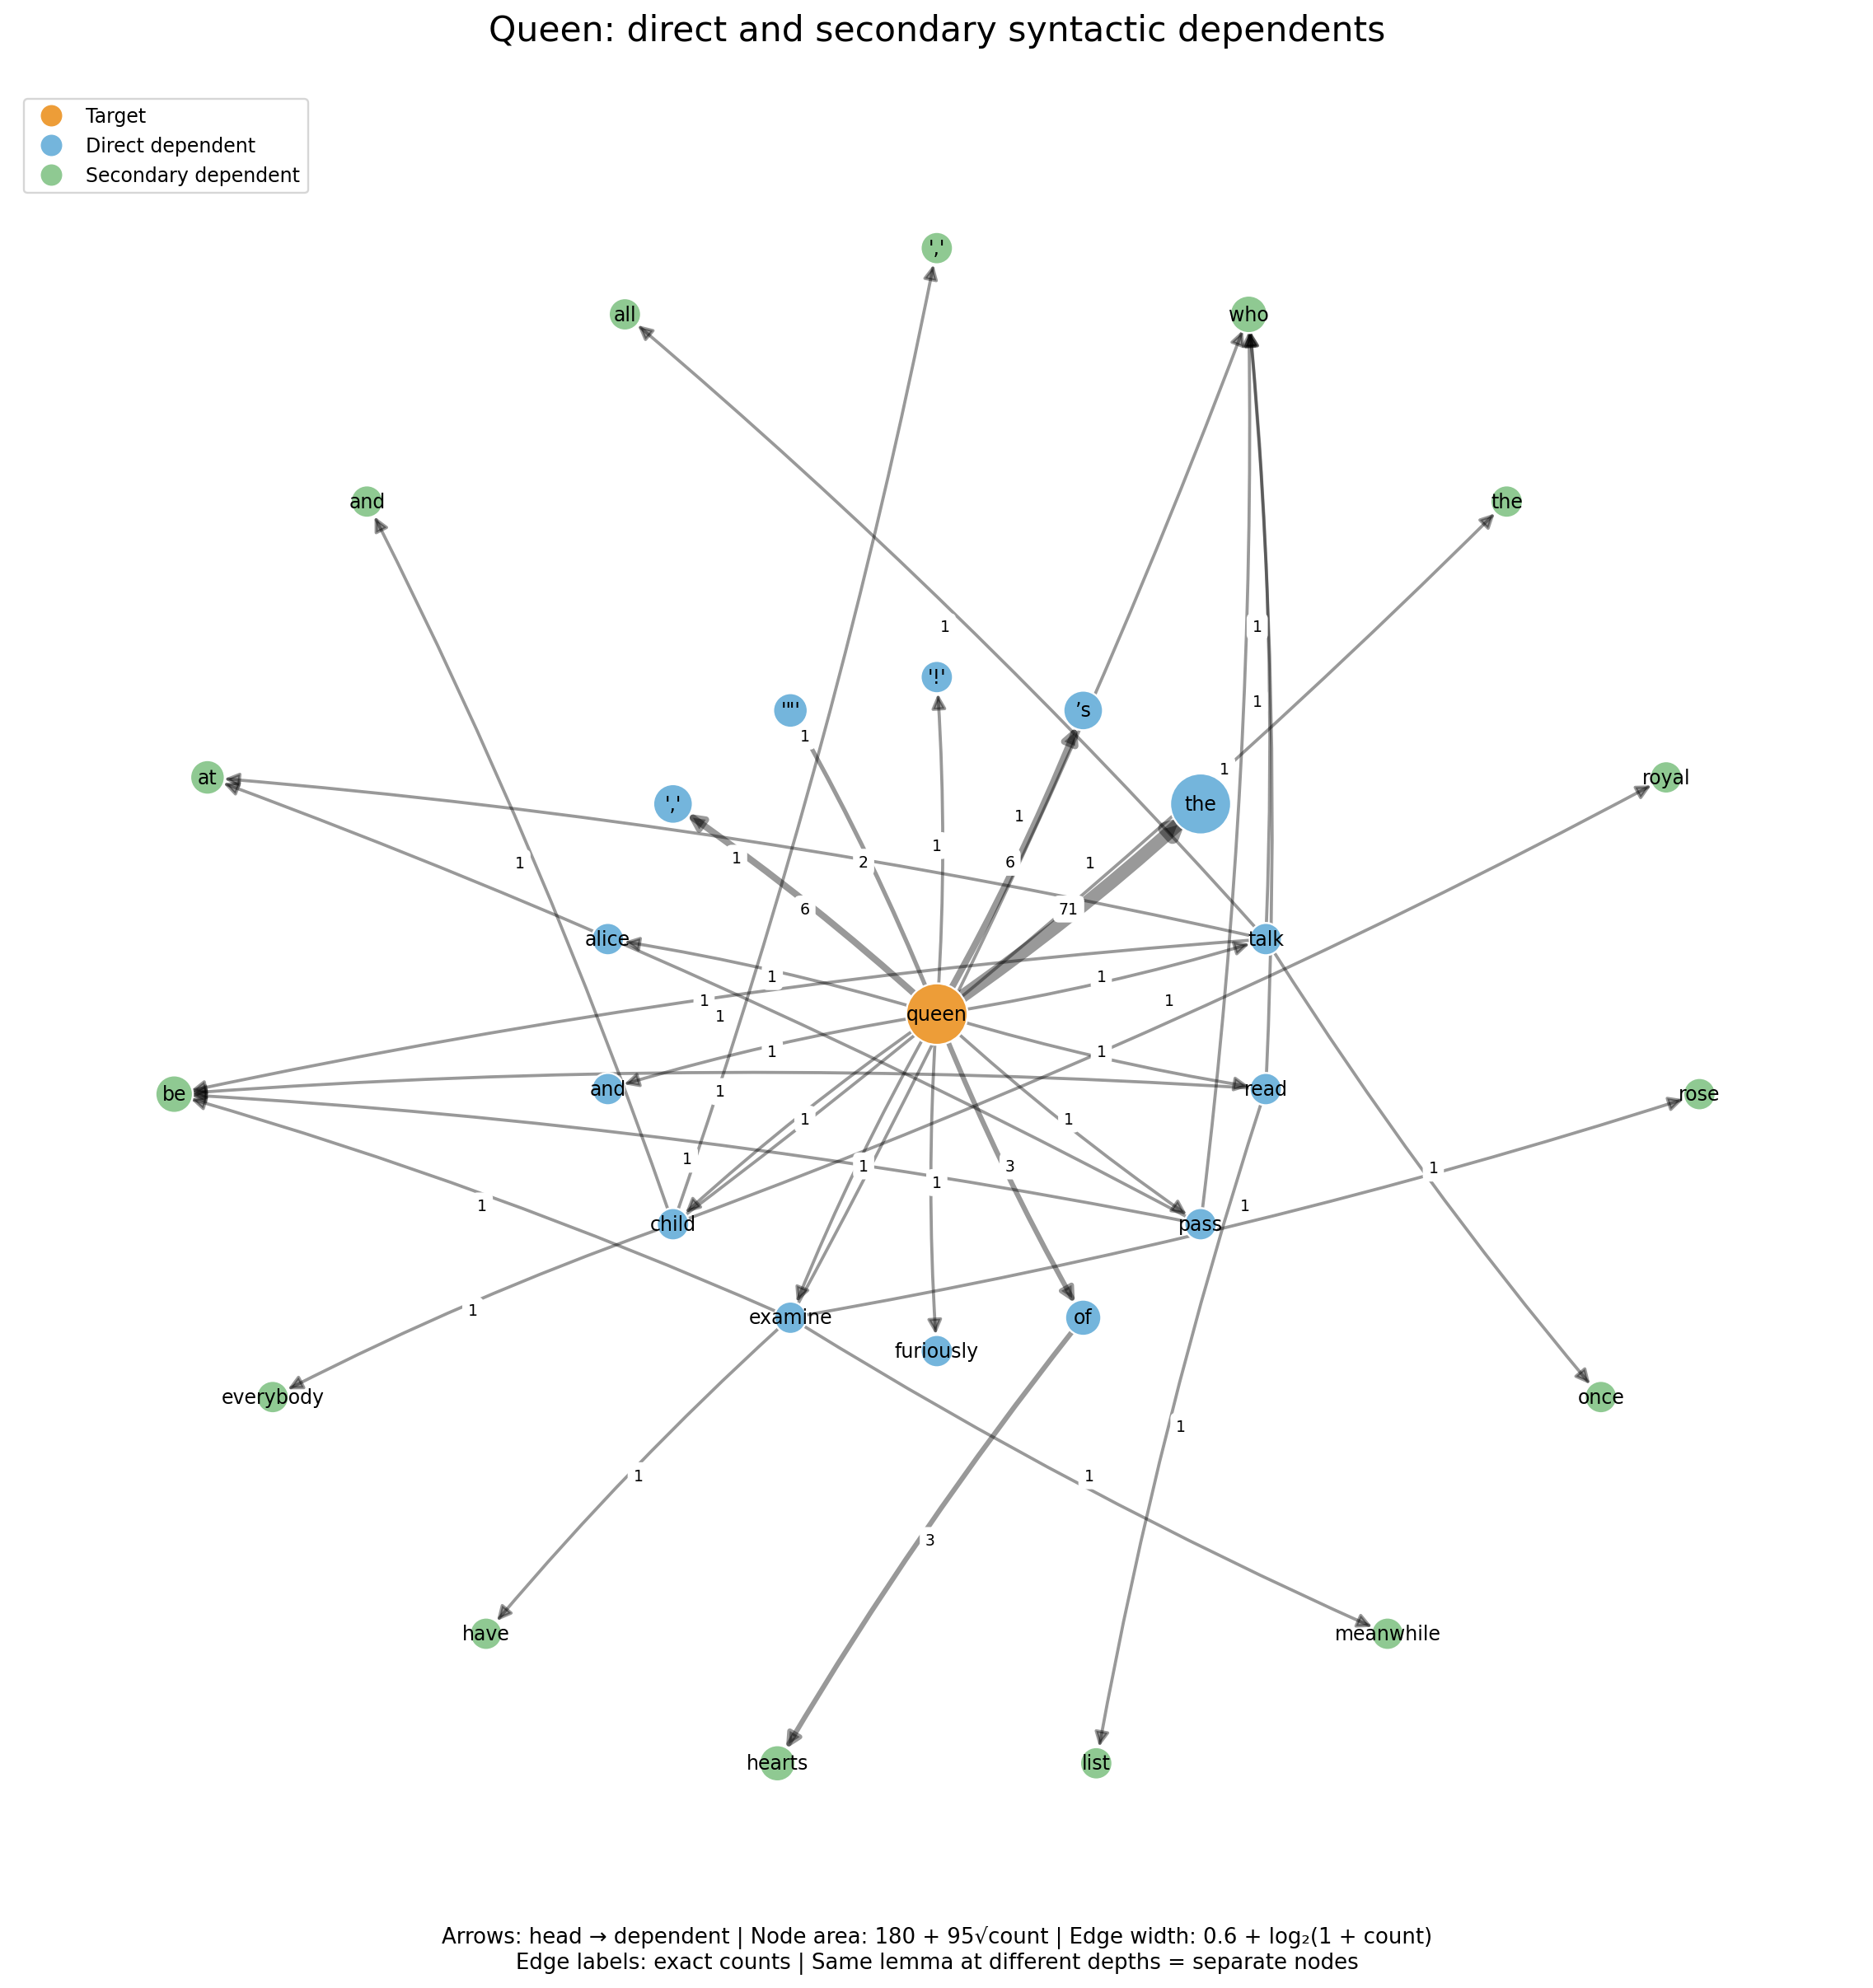

In [21]:
G = nx.DiGraph()
G.add_node('0:queen', lemma=TARGET, depth=0, count=target_count)
edge_counts, relation_counts, node_counts = Counter(), {}, Counter()
for r in occurrences:
    source = f"{r['depth']-1}:{r['head_lemma']}"
    dest = f"{r['depth']}:{r['dependent_lemma']}"
    edge_counts[source, dest] += 1
    node_counts[dest] += 1
    relation_counts.setdefault((source, dest), Counter())[r['relation']] += 1
for node, count in node_counts.items():
    depth, lemma = node.split(':', 1)
    G.add_node(node, lemma=lemma, depth=int(depth), count=count)
for (source, dest), weight in edge_counts.items():
    G.add_edge(source, dest, weight=weight, relations=json.dumps(dict(relation_counts[source, dest]), ensure_ascii=False))
assert sum(d['weight'] for _, _, d in G.edges(data=True)) == len(occurrences)
assert all(G.nodes[v]['depth'] == G.nodes[u]['depth']+1 for u,v in G.edges)
assert nx.is_directed_acyclic_graph(G)
assert nx.is_weakly_connected(G)
nx.write_graphml(G, OUT / 'dependency_network.graphml')
save_csv('nodes.csv', [dict(node=n, **d) for n,d in G.nodes(data=True)], ['node','lemma','depth','count'])
save_csv('edges.csv', [dict(source=u, target=v, **d) for u,v,d in G.edges(data=True)], ['source','target','weight','relations'])
pos = {'0:queen': (0,0)}
for depth, radius in [(1, 1.1), (2, 2.5)]:
    layer = sorted(n for n,d in G.nodes(data=True) if d['depth']==depth)
    for i,n in enumerate(layer):
        angle = 2*math.pi*i/max(1,len(layer)) + math.pi/2
        pos[n] = (radius*math.cos(angle), radius*math.sin(angle))
colours = {0:'#ed9d38',1:'#74b5dc',2:'#8fc992'}
labels = {n: repr(d['lemma']) if not any(c.isalnum() for c in d['lemma']) else d['lemma'] for n,d in G.nodes(data=True)}

def draw_network(path, community_map=None):
    fig, ax = plt.subplots(figsize=(17,17))
    node_colours = [colours[d['depth']] if community_map is None else plt.get_cmap('tab20')(community_map[n]%20) for n,d in G.nodes(data=True)]
    nx.draw_networkx_nodes(G,pos,node_color=node_colours,node_size=[180+95*math.sqrt(d['count']) for _,d in G.nodes(data=True)], edgecolors='white',ax=ax)
    nx.draw_networkx_edges(G,pos,width=[0.6+math.log2(1+d['weight']) for _,_,d in G.edges(data=True)],alpha=.4,arrows=True,arrowsize=15,connectionstyle='arc3,rad=0.035',ax=ax)
    nx.draw_networkx_labels(G,pos,labels,font_size=10,ax=ax)
    nx.draw_networkx_edge_labels(G,pos,edge_labels=nx.get_edge_attributes(G,'weight'),font_size=8,rotate=False,ax=ax)
    ax.set_title('Queen: direct and secondary syntactic dependents' + (' — communities' if community_map else ''), fontsize=18, pad=25)
    if community_map is None:
        ax.legend(handles=[Line2D([0],[0],marker='o',color='w',markerfacecolor=colours[i],markersize=12,label=s) for i,s in enumerate(['Target','Direct dependent','Secondary dependent'])],loc='upper left')
    ax.text(.5,-.025,'Arrows: head → dependent | Node area: 180 + 95√count | Edge width: 0.6 + log₂(1 + count)\nEdge labels: exact counts | Same lemma at different depths = separate nodes',transform=ax.transAxes,ha='center',fontsize=11)
    ax.axis('off')
    fig.savefig(OUT / path,dpi=170,bbox_inches='tight')
    plt.close(fig)

draw_network('dependency_network.png')
display(Image(filename=str(OUT/'dependency_network.png'), width=950))


## 5. Network analysis

### 5.1. Text Statistics and Graph Structure
**Density** is the number of distinct directed edges divided by `n(n−1)`; weights do not enter this measure. This conventional denominator permits many edges that the two-layer extraction cannot produce, so a low value should not be interpreted as weak association. I also report the fraction of possible edges under this design: `m / (n₁ + n₁n₂)`, where n₁ and n₂ are the two layer sizes.

**Connectivity and degree:** weak connectivity checks that all retained nodes link to the target. Strong components and acyclicity describe the effect of layering.


In [22]:
U = G.to_undirected()

communities = list(
    nx.community.greedy_modularity_communities(U, weight="weight")
)
community_map = {
    node: i
    for i, community in enumerate(communities)
    for node in community
}

n1 = sum(d["depth"] == 1 for _, d in G.nodes(data=True))
n2 = sum(d["depth"] == 2 for _, d in G.nodes(data=True))

metrics = dict(
    target=TARGET,
    target_occurrences=target_count,
    nonspace_tokens=len(token_rows),
    wordlike_tokens=sum(freq.values()),
    sentences=len(sentences),
    nodes=G.number_of_nodes(),
    edges=G.number_of_edges(),
    direct_nodes=n1,
    secondary_nodes=n2,
    dependency_instances=len(occurrences),
    directed_density=nx.density(G),
    layer_constrained_density=G.number_of_edges() / (n1 + n1 * n2),
    weak_components=nx.number_weakly_connected_components(G),
    strong_components=nx.number_strongly_connected_components(G),
    is_dag=nx.is_directed_acyclic_graph(G),
    communities=len(communities),
    weighted_modularity=nx.community.modularity(
        U, communities, weight="weight"
    )
)

(OUT / "metrics.json").write_text(
    json.dumps(metrics, indent=2),
    encoding="utf-8"
)

def show_table(rows, caption):
    display(
        pd.DataFrame(rows, columns=["Measure", "Value"])
        .style
        .hide(axis="index")
        .set_caption(caption)
        .set_properties(**{"text-align": "left", "padding": "8px"})
    )

show_table([
    ("Target lemma", TARGET),
    ("Target occurrences", target_count),
    ("Word-like tokens", sum(freq.values())),
    ("Sentences", len(sentences)),
    ("Extracted dependency instances", len(occurrences))
], "Text and extracted data")

show_table([
    ("Nodes", G.number_of_nodes()),
    ("Distinct directed edges", G.number_of_edges()),
    ("Direct dependent nodes", n1),
    ("Secondary dependent nodes", n2),
    ("Directed density", f"{metrics['directed_density']:.3f}"),
    ("Layer-constrained density",
     f"{metrics['layer_constrained_density']:.3f}"),
    ("Weakly connected components", metrics["weak_components"]),
    ("Strongly connected components", metrics["strong_components"]),
    ("Directed acyclic graph", metrics["is_dag"])
], "Graph structure")

Measure,Value
Target lemma,queen
Target occurrences,74
Word-like tokens,27216
Sentences,1521
Extracted dependency instances,121


Measure,Value
Nodes,30
Distinct directed edges,36
Direct dependent nodes,14
Secondary dependent nodes,15
Directed density,0.041
Layer-constrained density,0.161
Weakly connected components,1
Strongly connected components,30
Directed acyclic graph,True


The graph contains 30 nodes and 36 distinct directed edges, aggregating 121 dependency instances. Its directed density is 0.041; when only connections permitted by the layered design are considered, density is 0.161. The graph has one weakly connected component and no directed cycles, as expected from its construction: every node is connected to the target, and edges always lead to the next layer.

### 5.2. Communities
**Communities:** I apply greedy modularity maximization to an undirected projection with the same edge weights. The projection is used only for this calculation, to group strongly connected nodes irrespective of arrow direction. The algorithm is deterministic for this fixed graph and node order. Modularity is reported relative to the weighted degree-based null model; it is not a significance test. Communities may mainly reflect shared function words or the imposed layers, so I do not treat them as semantic themes.

In [23]:
community_rows = [
    dict(
        community=community_map[node] + 1,
        node=node,
        lemma=d["lemma"],
        depth=d["depth"],
        count=d["count"]
    )
    for node, d in G.nodes(data=True)
]

save_csv(
    "communities.csv",
    community_rows,
    ["community", "node", "lemma", "depth", "count"]
)

community_summary = []

for i, community in enumerate(communities, 1):
    row = {"Community": i}

    for depth, label in [
        (0, "Target"),
        (1, "Direct dependents"),
        (2, "Secondary dependents")
    ]:
        lemmas = sorted(
            repr(G.nodes[node]["lemma"])
            for node in community
            if G.nodes[node]["depth"] == depth
        )
        row[label] = ", ".join(lemmas) or "—"

    community_summary.append(row)

display(
    pd.DataFrame(community_summary)
    .style
    .hide(axis="index")
    .set_caption(
        f"Communities: {len(communities)} | "
        f"Weighted modularity: {metrics['weighted_modularity']:.3f}"
    )
    .set_properties(**{
        "text-align": "left",
        "white-space": "normal",
        "padding": "8px"
    })
)

Community,Target,Direct dependents,Secondary dependents
1,—,"'examine', 'pass', 'read', 'talk'","'all', 'at', 'be', 'have', 'list', 'meanwhile', 'once', 'rose', 'who'"
2,'queen',"'!', '""', ',', 'alice', 'and', 'furiously', 'the', '’s'",—
3,—,'child',"',', 'and', 'everybody', 'royal', 'the'"
4,—,'of','hearts'


The algorithm identifies four communities, with weighted modularity of 0.318. One groups relative-clause verbs such as examine, pass, read, and talk with their dependents; another contains the target and frequent direct dependents such as the. The remaining groups contain the child branch and the expression of Hearts. These communities reflect local grammatical and lexical patterns and should not automatically be interpreted as semantic themes.

### 5.3. Out-Degree and Weighted Out-Degree
**Degree:** weighted out-degree (out-strength) counts extracted dependent instances, whereas ordinary out-degree counts distinct dependent nodes. These are local syntactic counts, not measures of a character’s narrative importance.

In [24]:
degree_rows = [
    {
        "Lemma": d["lemma"],
        "Depth": d["depth"],
        "Distinct children": G.out_degree(node),
        "Dependency instances": G.out_degree(node, weight="weight")
    }
    for node, d in G.nodes(data=True)
    if d["depth"] != 0 and G.out_degree(node) > 0
]

degree_table = (
    pd.DataFrame(degree_rows)
    .sort_values(
        ["Dependency instances", "Distinct children", "Lemma"],
        ascending=[False, False, True]
    )
    .head(10)
)

display(
    degree_table.style
    .hide(axis="index")
    .set_caption("Noncentral nodes with outgoing dependencies")
    .set_properties(**{"text-align": "left", "padding": "8px"})
)

Lemma,Depth,Distinct children,Dependency instances
child,1,5,5
examine,1,5,5
talk,1,5,5
pass,1,3,3
read,1,3,3
of,1,1,3


The node child has five distinct children and five dependency instances. This describes the structure of its extracted phrase, rather than its frequency or importance in the novel. Outgoing dependency counts must therefore be interpreted as local grammatical properties.

### 5.4. Visualizing the Communities
Colours now indicate community membership, while positions still indicate dependency depth. Node sizes and edge widths retain the frequency encoding used in the previous graph.

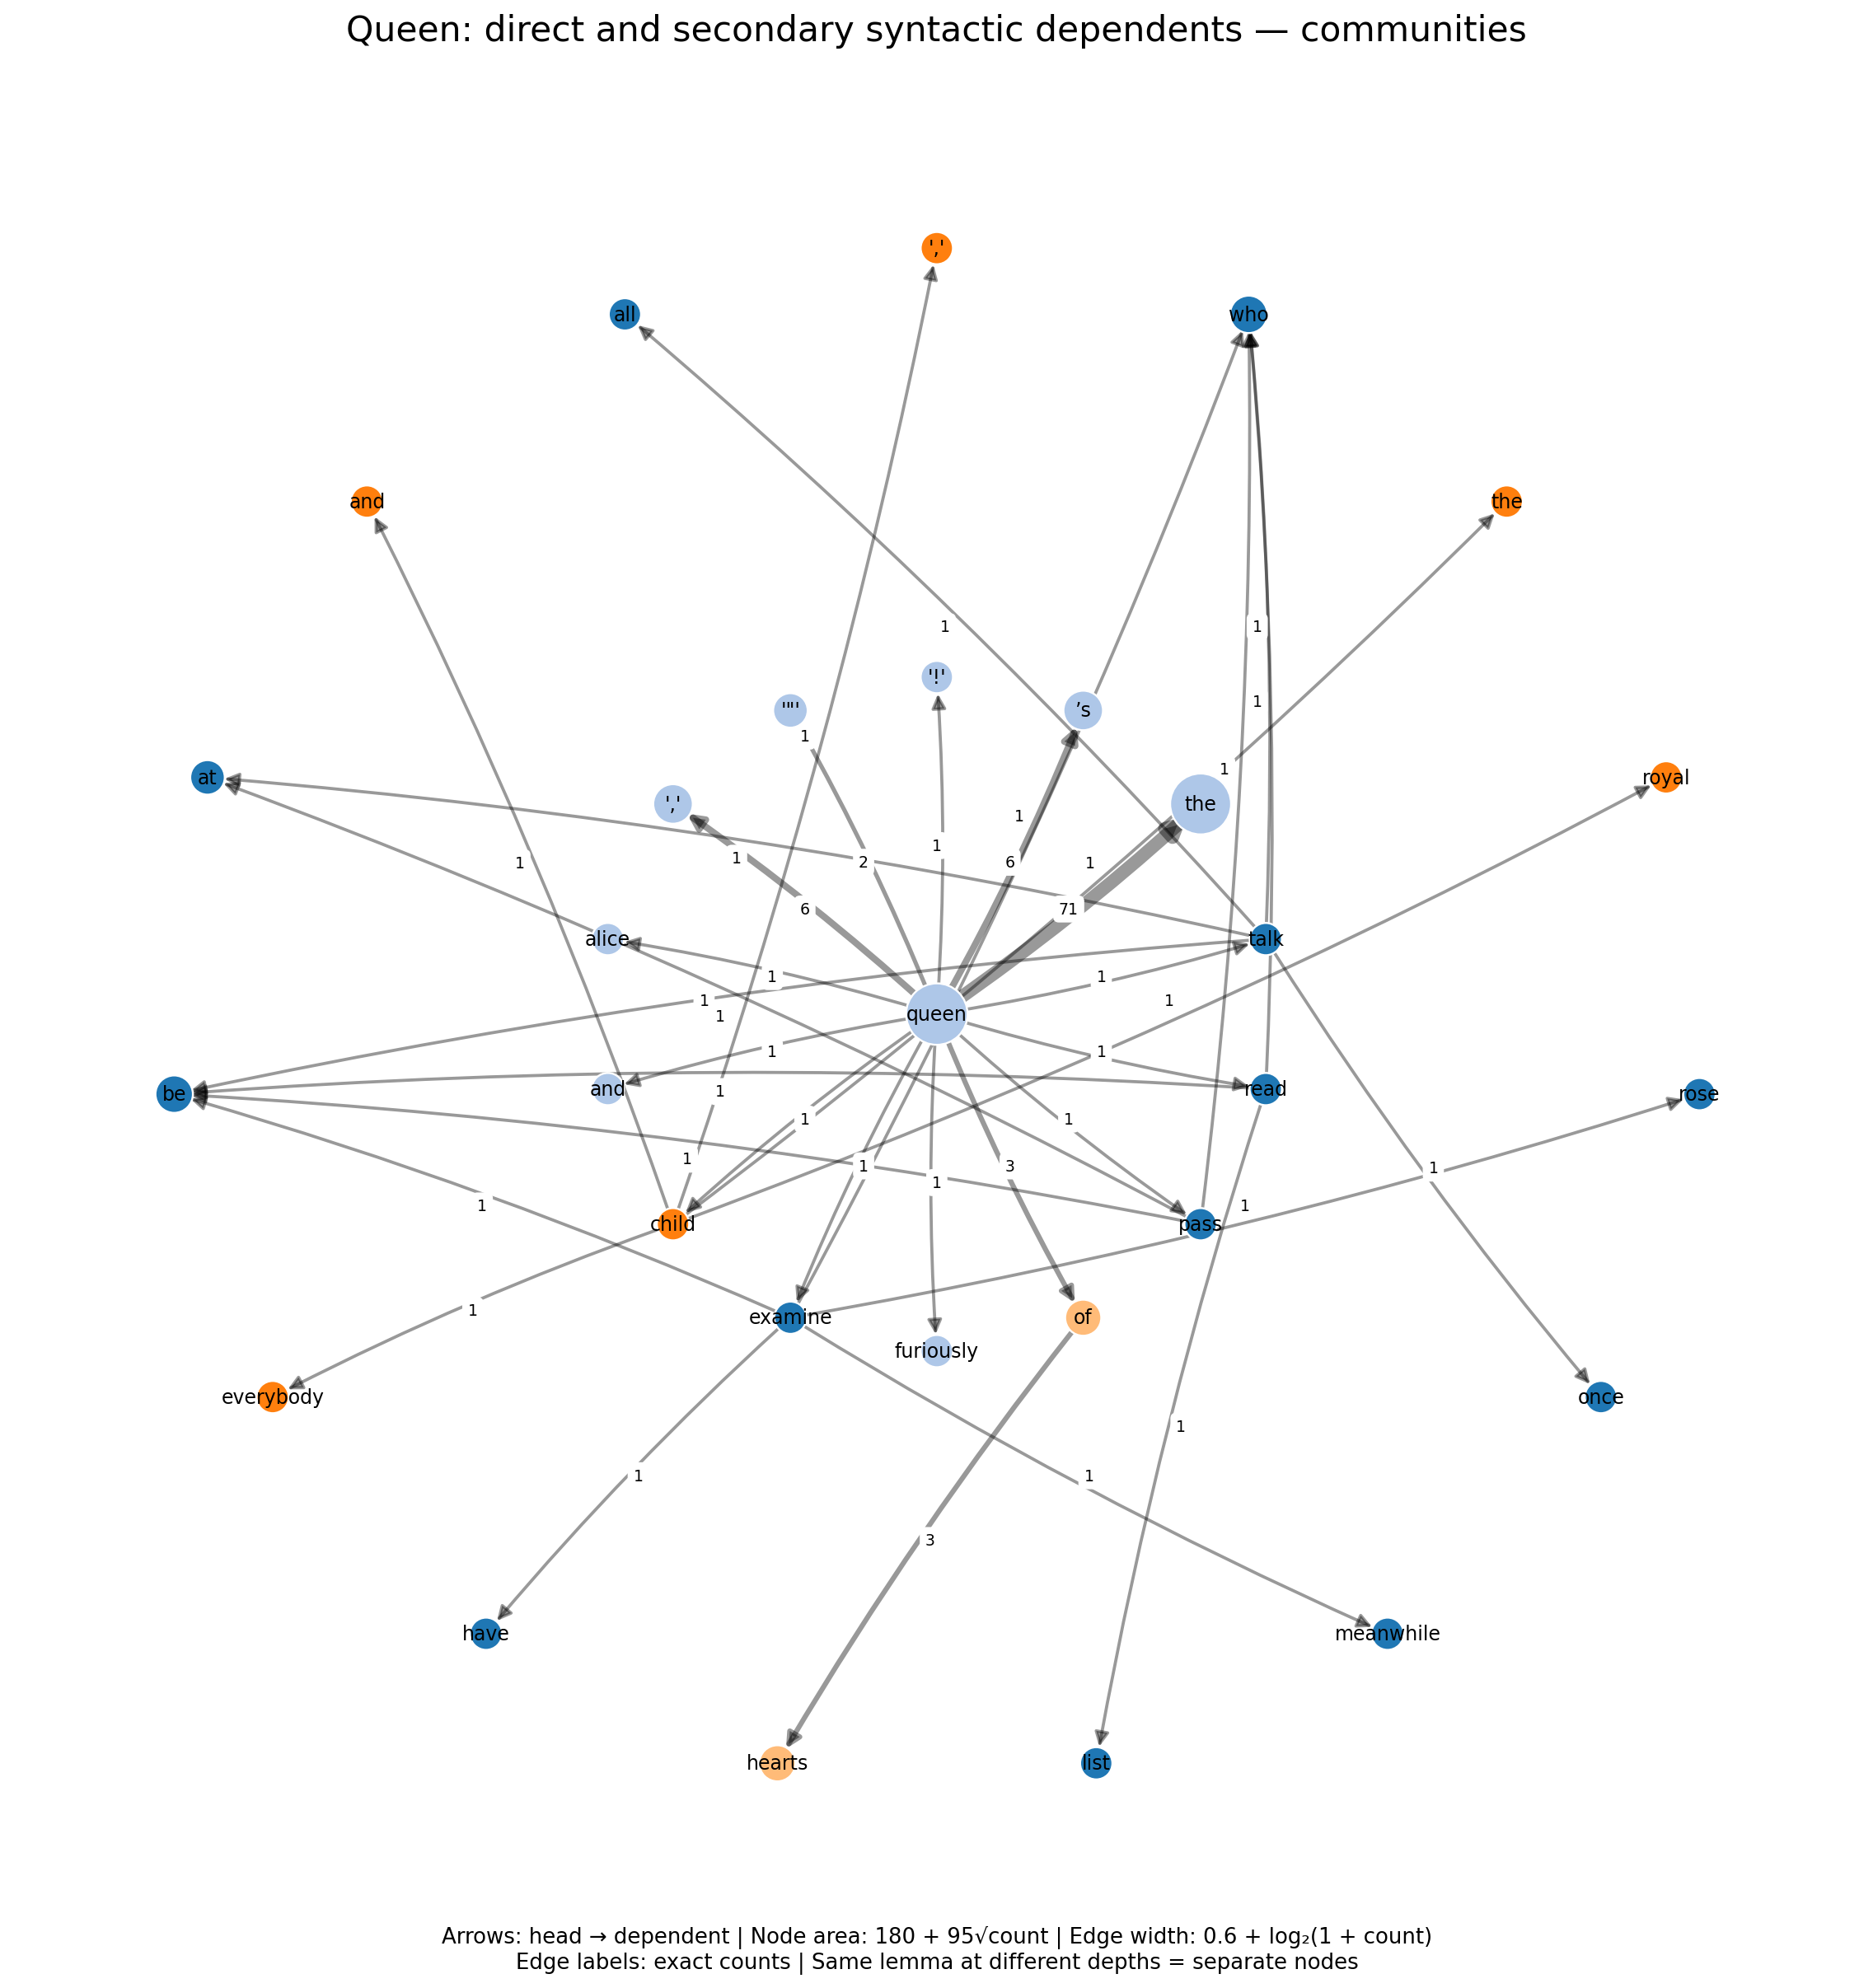

In [25]:
draw_network("communities.png", community_map)

display(
    Image(
        filename=str(OUT / "communities.png"),
        width=950
    )
)

## 6. Interpretation and limitations
The strongest observations concern the Queen’s local grammatical contexts. A two-step dependency network cannot establish sentiment, social relationships between characters, or a novel-wide semantic structure. All reported counts depend on the automatic parse; retaining sentences and token IDs allows individual errors to be checked.

The standard directed density is about 0.041, compared with 0.161 when only permitted layer-to-layer pairs are counted. Both quantify sparsity, but the second better reflects this extraction design. There are four communities (weighted modularity about 0.318): the target and its frequent determiners/punctuation; a group of relative-clause verbs and shared dependents; a branch headed by *child*; and *of → hearts*. This grouping mixes grammatical and lexical regularities. One weak component and 30 singleton strong components are expected consequences of connected outward layers, not independent linguistic discoveries.

For example, “the Queen, who was reading the list of singers” gives `queen → read` (relative clause), followed by `read → who`, `read → be`, and `read → list`. The direct `queen → the` dependency is separate. The model retains *Hearts* as the lemma `hearts`, reflecting its analysis as a proper name. Unusual edges, especially around dialogue punctuation, should be inspected in the supplied sentences before making stronger claims.


In [26]:
direct = Counter(r['dependent_lemma'] for r in occurrences if r['depth']==1)
secondary = Counter(r['dependent_lemma'] for r in occurrences if r['depth']==2)
summary = (f"The dominant direct dependency is queen → the ({direct['the']} instances across {target_count} occurrences), showing that the character is usually referred to with a definite title; the queen → of → hearts path occurs three times and recovers the fuller title 'Queen of Hearts'. "
           "A separate community links the relative-clause verbs examine, pass, read, and talk through dependents such as who and be, illustrating a recurrent grammatical construction rather than a coherent semantic theme.")
print(summary)
report = '# HW1 results — Akhmed Dugrichilov\n\n' + summary + '\n\n## Network measures\n\n'
report += '\n'.join(f'- {k}: {v}' for k,v in metrics.items())
report += '\n\n## Community membership\n\n' + '\n'.join(f"- Community {i}: {', '.join(sorted(c))}" for i,c in enumerate(communities,1))
report += '\n\nDensity uses distinct edges, not frequency. The graph is connected and acyclic by construction. Communities use the weighted undirected projection and should not be equated with semantic topics. See the notebook for full methods, parameter justifications, and limitations.\n'
(OUT/'results.md').write_text(report,encoding='utf-8')


The dominant direct dependency is queen → the (71 instances across 74 occurrences), showing that the character is usually referred to with a definite title; the queen → of → hearts path occurs three times and recovers the fuller title 'Queen of Hearts'. A separate community links the relative-clause verbs examine, pass, read, and talk through dependents such as who and be, illustrating a recurrent grammatical construction rather than a coherent semantic theme.


1528